# Phân tích khám phá dữ liệu cường độ chịu nén bê tông

**Bộ dữ liệu:** UCI Concrete Compressive Strength  
**Mục tiêu:** mô tả cấu trúc dữ liệu, kiểm tra chất lượng, xây dựng biến phụ trợ, trực quan hóa các mối quan hệ chính và đánh giá ngoại lai trước các bước phân tích hoặc mô hình hóa tiếp theo.

## 1. Import và thiết lập môi trường

Trước tiên, nạp các thư viện cần thiết cho xử lý bảng, thống kê và trực quan hóa. Thiết lập hiển thị nhất quán giúp các bảng và hình có thể dùng trực tiếp trong báo cáo.

In [4]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

Tiếp theo, xác định thư mục gốc dự án và tạo các thư mục đầu ra.

In [5]:
project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw" / "Concrete_Data.xls").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "raw" / "Concrete_Data.xls"
figures_dir = project_root / "figures"
tables_dir = project_root / "tables"
processed_dir = project_root / "data" / "processed"

for directory in (figures_dir, tables_dir, processed_dir):
    directory.mkdir(parents=True, exist_ok=True)

**Nhận xét.** Toàn bộ hình, bảng và dữ liệu đã xử lý sẽ được ghi vào các thư mục chuẩn của dự án, nhờ đó notebook không phụ thuộc vào đường dẫn tuyệt đối trên một máy cụ thể.

### Hàm tiện ích

Các hàm dưới đây đảm nhiệm hai việc lặp lại xuyên suốt notebook: lưu hình ở độ phân giải 300 dpi và xác định ngoại lai bằng IQR, Z-score, Modified Z-score. Modified Z-score được đánh dấu là không áp dụng khi MAD bằng 0, vì khi đó không thể chia cho độ lệch tuyệt đối trung vị.

In [6]:
def save_figure(filename: str) -> None:
    # Lưu hình hiện tại ở định dạng PNG, 300 dpi.
    plt.savefig(figures_dir / filename, dpi=300, bbox_inches="tight", facecolor="white")


def iqr_outlier_flags(series: pd.Series, multiplier: float = 1.5):
    # Trả về cờ ngoại lai IQR và hai ngưỡng dưới/trên.
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return (series < lower) | (series > upper), lower, upper


def zscore_outlier_flags(series: pd.Series, threshold: float = 3.0):
    # Trả về cờ ngoại lai theo |Z-score| > threshold.
    std = series.std(ddof=0)
    if std == 0:
        return pd.Series(False, index=series.index), np.nan, np.nan
    scores = (series - series.mean()) / std
    lower = series.mean() - threshold * std
    upper = series.mean() + threshold * std
    return scores.abs() > threshold, lower, upper


def modified_z_outlier_flags(series: pd.Series, threshold: float = 3.5):
    # Trả về cờ Modified Z-score, ngưỡng dữ liệu và trạng thái áp dụng.
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return pd.Series(False, index=series.index), np.nan, np.nan, False, mad
    scores = 0.6745 * (series - median) / mad
    delta = threshold * mad / 0.6745
    return scores.abs() > threshold, median - delta, median + delta, True, mad


print("Đã định nghĩa các hàm lưu hình và phát hiện ngoại lai.")

Đã định nghĩa các hàm lưu hình và phát hiện ngoại lai.


**Nhận xét.** Việc gom công thức phát hiện ngoại lai vào hàm giúp tất cả biến được đánh giá theo cùng một quy tắc và giảm nguy cơ sai khác khi lặp lại phép tính.

## 2. Đọc và tóm tắt dữ liệu

Dữ liệu được đọc trực tiếp từ tệp Excel cũ bằng `pd.read_excel(engine="xlrd")`. Ngay sau khi đọc, chín tên cột dài của nguồn được đổi sang tên ngắn, dễ dùng trong mã và biểu đồ.

In [7]:
raw_df = pd.read_excel(data_path, engine="xlrd")
short_columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "strength"
]
original_columns = raw_df.columns.tolist()
if raw_df.shape[1] != len(short_columns):
    raise ValueError(f"Số cột thực tế ({raw_df.shape[1]}) không khớp với 9 cột mong đợi.")
raw_df.columns = short_columns

display(raw_df.head())

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.000,0.000,0.000,162.000,2.500,"1,040.000",676.000,28,79.986
1,540.000,0.000,0.000,162.000,2.500,"1,055.000",676.000,28,61.887
2,332.500,142.500,0.000,228.000,0.000,932.000,594.000,270,40.270
3,332.500,142.500,0.000,228.000,0.000,932.000,594.000,365,41.053
4,198.600,132.400,0.000,192.000,0.000,978.400,825.500,360,44.296


**Nhận xét.** Tệp được đọc thành công với 1.030 quan sát và 9 biến. Các tên ngắn vẫn giữ nguyên ý nghĩa và thứ tự của nguồn UCI.

Bảng khái quát sau kiểm tra kích thước, kiểu dữ liệu và số giá trị khác nhau. Đây là bước nhanh để phát hiện cột bị đọc sai kiểu hoặc biến có ít mức rời rạc.

In [8]:
structure_summary = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "so_khong_thieu": raw_df.notna().sum(),
    "so_gia_tri_khac_nhau": raw_df.nunique(dropna=True),
})
print(f"Kích thước dữ liệu: {raw_df.shape[0]:,} dòng × {raw_df.shape[1]} cột")
display(structure_summary)

Kích thước dữ liệu: 1,030 dòng × 9 cột


,dtype,so_khong_thieu,so_gia_tri_khac_nhau
cement,float64,1030,280
slag,float64,1030,187
fly_ash,float64,1030,163
water,float64,1030,205
superplasticizer,float64,1030,155
coarse_agg,float64,1030,284
fine_agg,float64,1030,304
age,int64,1030,14
strength,float64,1030,938


**Nhận xét.** Tám biến được đọc ở dạng `float64`, riêng `age` là `int64`. Không có biến phân loại trong dữ liệu gốc. `age` chỉ có 14 giá trị khác nhau, nên dù là biến số, đây là lịch thử nghiệm theo các mốc ngày rời rạc.

`DataFrame.info()` cung cấp một kiểm tra độc lập về số lượng giá trị không thiếu và mức sử dụng bộ nhớ.

In [9]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_agg        1030 non-null   float64
 6   fine_agg          1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


**Nhận xét.** Cả 9 cột đều có đủ 1.030 giá trị không thiếu; bộ dữ liệu nhỏ, có thể phân tích trực tiếp trong bộ nhớ.

### Từ điển dữ liệu

Bảng từ điển làm rõ tên biến, ý nghĩa, đơn vị và vai trò. Điều này đặc biệt quan trọng vì bảy biến thành phần dùng cùng đơn vị kg/m³ nhưng có vai trò vật liệu khác nhau.

In [10]:
data_dictionary = pd.DataFrame([
    ["cement", "Xi măng trong hỗn hợp", "kg/m³", "Biến đầu vào"],
    ["slag", "Xỉ lò cao nghiền mịn", "kg/m³", "Biến đầu vào"],
    ["fly_ash", "Tro bay", "kg/m³", "Biến đầu vào"],
    ["water", "Nước trộn", "kg/m³", "Biến đầu vào"],
    ["superplasticizer", "Phụ gia siêu dẻo", "kg/m³", "Biến đầu vào"],
    ["coarse_agg", "Cốt liệu thô", "kg/m³", "Biến đầu vào"],
    ["fine_agg", "Cốt liệu mịn", "kg/m³", "Biến đầu vào"],
    ["age", "Tuổi mẫu khi thử nén", "ngày", "Biến đầu vào"],
    ["strength", "Cường độ chịu nén bê tông", "MPa", "Biến mục tiêu"],
], columns=["ten_bien", "y_nghia", "don_vi", "vai_tro"])

data_dictionary.to_csv(tables_dir / "data_dictionary.csv", index=False, encoding="utf-8-sig")
display(data_dictionary)

,ten_bien,y_nghia,don_vi,vai_tro
0,cement,Xi măng trong hỗn hợp,kg/m³,Biến đầu vào
1,slag,Xỉ lò cao nghiền mịn,kg/m³,Biến đầu vào
2,fly_ash,Tro bay,kg/m³,Biến đầu vào
3,water,Nước trộn,kg/m³,Biến đầu vào
4,superplasticizer,Phụ gia siêu dẻo,kg/m³,Biến đầu vào
5,coarse_agg,Cốt liệu thô,kg/m³,Biến đầu vào
6,fine_agg,Cốt liệu mịn,kg/m³,Biến đầu vào
7,age,Tuổi mẫu khi thử nén,ngày,Biến đầu vào
8,strength,Cường độ chịu nén bê tông,MPa,Biến mục tiêu


**Nhận xét.** Bài toán có 8 biến đầu vào định lượng và 1 biến mục tiêu định lượng là `strength`; do đó EDA tập trung vào phân phối, ngoại lai và quan hệ đơn điệu/liên tục giữa các biến số.

## 3. Làm sạch dữ liệu

### 3.1. Kiểm tra dòng trùng

Dòng trùng hoàn toàn có thể làm tăng trọng số của một cấp phối trong thống kê mô tả. Vì không có mã mẫu riêng để phân biệt các phép thử lặp, notebook xem các bản ghi giống nhau ở cả 9 cột là trùng và giữ bản xuất hiện đầu tiên.

In [11]:
duplicate_count = int(raw_df.duplicated(keep="first").sum())
print(f"Số dòng trùng hoàn toàn: {duplicate_count}")
display(raw_df.loc[raw_df.duplicated(keep=False)].head(10))

Số dòng trùng hoàn toàn: 25


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
72,425.000,106.300,0.000,153.500,16.500,852.100,887.100,3,33.398
77,425.000,106.300,0.000,153.500,16.500,852.100,887.100,3,33.398
80,425.000,106.300,0.000,153.500,16.500,852.100,887.100,3,33.398
83,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
86,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
88,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
91,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
95,425.000,106.300,0.000,153.500,16.500,852.100,887.100,7,49.201
100,425.000,106.300,0.000,153.500,16.500,852.100,887.100,7,49.201
103,425.000,106.300,0.000,153.500,16.500,852.100,887.100,7,49.201


**Nhận xét.** Có 25 dòng trùng hoàn toàn. Các dòng này không mang thêm thông tin phân biệt về mẫu, nên sẽ được loại để tránh lặp trọng số trong EDA.

Thực hiện khử trùng và khởi tạo nhật ký làm sạch. Nhật ký ghi rõ số dòng trước, số dòng loại, số dòng sau và lý do của từng bước.

In [12]:
clean_df = raw_df.drop_duplicates(keep="first").reset_index(drop=True).copy()
cleaning_records = [
    {
        "buoc": "Nạp dữ liệu gốc",
        "so_dong_truoc": len(raw_df),
        "so_dong_loai": 0,
        "so_dong_sau": len(raw_df),
        "ly_do": "Giữ nguyên toàn bộ bản ghi khi đọc tệp nguồn.",
    },
    {
        "buoc": "Xóa dòng trùng hoàn toàn",
        "so_dong_truoc": len(raw_df),
        "so_dong_loai": duplicate_count,
        "so_dong_sau": len(clean_df),
        "ly_do": "Các dòng giống nhau ở cả 9 cột không có mã mẫu để phân biệt.",
    },
]
print(f"Kích thước sau khử trùng: {clean_df.shape[0]:,} dòng × {clean_df.shape[1]} cột")

Kích thước sau khử trùng: 1,005 dòng × 9 cột


**Nhận xét.** Sau khi giữ bản xuất hiện đầu tiên của mỗi dòng, dữ liệu còn 1.005 quan sát, tương đương loại 2,43% số dòng ban đầu.

### 3.2. Kiểm tra giá trị thiếu

Đếm NaN theo từng cột để xác nhận thông tin mô tả của UCI và tránh nhầm số 0 hợp lệ với giá trị thiếu.

In [13]:
missing_summary = pd.DataFrame({
    "so_luong_thieu": clean_df.isna().sum(),
    "ty_le_thieu_pct": clean_df.isna().mean().mul(100),
})
cleaning_records.append({
    "buoc": "Kiểm tra giá trị thiếu",
    "so_dong_truoc": len(clean_df),
    "so_dong_loai": 0,
    "so_dong_sau": len(clean_df),
    "ly_do": "Không có NaN; không cần điền khuyết hoặc loại dòng.",
})
display(missing_summary)

,so_luong_thieu,ty_le_thieu_pct
cement,0,0.000
slag,0,0.000
fly_ash,0,0.000
water,0,0.000
superplasticizer,0,0.000
coarse_agg,0,0.000
fine_agg,0,0.000
age,0,0.000
strength,0,0.000


**Nhận xét.** Không có NaN ở bất kỳ cột nào. Vì vậy notebook không thực hiện nội suy hoặc điền khuyết.

### 3.3. Kiểm tra số 0 và giá trị không dương bất hợp lý

Với xi măng, nước, cốt liệu, tuổi và cường độ, giá trị không dương là bất hợp lý về mặt vật lý hoặc phép đo. Kiểm tra dùng điều kiện `<= 0` để phát hiện cả số 0 lẫn số âm.

In [14]:
required_positive = ["cement", "water", "coarse_agg", "fine_agg", "age", "strength"]
nonpositive_summary = pd.DataFrame({
    "so_gia_tri_khong_duong": (clean_df[required_positive] <= 0).sum(),
    "gia_tri_nho_nhat": clean_df[required_positive].min(),
})
invalid_rows = int((clean_df[required_positive] <= 0).any(axis=1).sum())
cleaning_records.append({
    "buoc": "Kiểm tra giá trị không dương bất hợp lý",
    "so_dong_truoc": len(clean_df),
    "so_dong_loai": 0,
    "so_dong_sau": len(clean_df),
    "ly_do": "Không có cement, water, aggregate, age hoặc strength <= 0.",
})
display(nonpositive_summary)

,so_gia_tri_khong_duong,gia_tri_nho_nhat
cement,0,102.000
water,0,121.750
coarse_agg,0,801.000
fine_agg,0,594.000
age,0,1.000
strength,0,2.332


**Nhận xét.** Không phát hiện giá trị không dương ở các biến bắt buộc phải dương. Đặc biệt, không có phép chia cho 0 khi tạo tỷ lệ nước/xi măng.

Slag, fly ash và superplasticizer có thể bằng 0 vì một cấp phối có thể không sử dụng vật liệu đó. Vì vậy, các số 0 này được thống kê riêng và giữ nguyên, không chuyển thành NaN.

In [15]:
optional_zero_columns = ["slag", "fly_ash", "superplasticizer"]
optional_zero_summary = pd.DataFrame({
    "so_luong_bang_0": (clean_df[optional_zero_columns] == 0).sum(),
    "ty_le_bang_0_pct": (clean_df[optional_zero_columns] == 0).mean().mul(100),
})
cleaning_records.append({
    "buoc": "Xác nhận số 0 hợp lệ ở vật liệu tùy chọn",
    "so_dong_truoc": len(clean_df),
    "so_dong_loai": 0,
    "so_dong_sau": len(clean_df),
    "ly_do": "Số 0 ở slag, fly_ash và superplasticizer nghĩa là không sử dụng.",
})
display(optional_zero_summary)

,so_luong_bang_0,ty_le_bang_0_pct
slag,465,46.269
fly_ash,541,53.831
superplasticizer,378,37.612


**Nhận xét.** Sau khử trùng, tỷ lệ bằng 0 là 46,3% với slag, 53,8% với fly ash và 37,6% với superplasticizer. Đây là đặc điểm cấu trúc của công thức cấp phối, không phải dữ liệu thiếu.

Nhật ký tạm thời được lưu ngay sau các kiểm tra chất lượng cơ bản; phần ngoại lai sẽ bổ sung thêm một dòng quyết định xử lý ở phần sau.

In [16]:
cleaning_log = pd.DataFrame(cleaning_records)
cleaning_log.to_csv(tables_dir / "cleaning_log.csv", index=False, encoding="utf-8-sig")
display(cleaning_log)

,buoc,so_dong_truoc,so_dong_loai,so_dong_sau,ly_do
0,Nạp dữ liệu gốc,1030,0,1030,Giữ nguyên toàn bộ bản ghi khi đọc tệp nguồn.
1,Xóa dòng trùng hoàn toàn,1030,25,1005,Các dòng giống nhau ở cả 9 cột không có mã mẫu...
2,Kiểm tra giá trị thiếu,1005,0,1005,Không có NaN; không cần điền khuyết hoặc loại ...
3,Kiểm tra giá trị không dương bất hợp lý,1005,0,1005,"Không có cement, water, aggregate, age hoặc st..."
4,Xác nhận số 0 hợp lệ ở vật liệu tùy chọn,1005,0,1005,"Số 0 ở slag, fly_ash và superplasticizer nghĩa..."


**Nhận xét.** Tại thời điểm này, chỉ bước khử trùng làm giảm số dòng; các kiểm tra thiếu và tính hợp lệ vật lý không phát hiện bản ghi cần loại.

## 4. Tạo biến phụ trợ

### 4.1. `log_age`

Tuổi có đuôi phải dài. Biến `log_age = log(1 + age)` nén các mốc tuổi lớn và thường làm quan hệ với cường độ dễ quan sát hơn, đồng thời vẫn xác định tại tuổi 0 nếu có dữ liệu mới.

In [17]:
clean_df["log_age"] = np.log1p(clean_df["age"])
display(clean_df[["age", "log_age"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"1,005.000",45.857,63.735,1.000,7.000,28.000,56.000,365.000
log_age,"1,005.000",3.245,1.109,0.693,2.079,3.367,4.043,5.903


**Nhận xét.** Độ lệch của `age` là 3,254, trong khi `log_age` gần đối xứng với độ lệch 0,006. Phép biến đổi đã giảm rõ rệt ảnh hưởng của các mốc 180–365 ngày.

### 4.2. `w_c`

Tỷ lệ nước/xi măng là chỉ báo kỹ thuật quen thuộc của cấp phối. Biến được tính bằng `water / cement`; ở đây phép chia an toàn vì cement không có giá trị 0.

In [18]:
clean_df["w_c"] = clean_df["water"] / clean_df["cement"]
display(clean_df["w_c"].describe().to_frame().T)

,count,mean,std,min,25%,50%,75%,max
w_c,"1,005.000",0.756,0.314,0.267,0.547,0.690,0.938,1.882


**Nhận xét.** `w_c` có trung vị 0,690, khoảng tứ phân vị 0,547–0,938 và phạm vi 0,267–1,882. Các giá trị cao cần được theo dõi nhưng không phải lỗi chia cho 0.

### 4.3. `age_group`

Tuổi được chia thành ba giai đoạn có ý nghĩa diễn giải: sớm (1–7 ngày), tiêu chuẩn (8–28 ngày) và dài ngày (>28 ngày). Cách chia này bám theo các mốc dưỡng hộ thường dùng và vẫn giữ đủ quan sát trong từng nhóm.

In [19]:
age_group_order = ["Sớm (1–7 ngày)", "Tiêu chuẩn (8–28 ngày)", "Dài ngày (>28 ngày)"]
clean_df["age_group"] = pd.cut(
    clean_df["age"],
    bins=[0, 7, 28, np.inf],
    labels=age_group_order,
    include_lowest=True,
)
display(clean_df["age_group"].value_counts(sort=False).to_frame("so_luong"))

,so_luong
age_group,
Sớm (1–7 ngày),253
Tiêu chuẩn (8–28 ngày),481
Dài ngày (>28 ngày),271


**Nhận xét.** Ba nhóm lần lượt có 253, 481 và 271 quan sát. Nhóm 8–28 ngày lớn nhất do riêng mốc 28 ngày đã chiếm 419 quan sát.

### 4.4. `scm_type`

Slag và fly ash là vật liệu bổ sung xi măng (SCM). Kết hợp hai cột thành bốn nhóm giúp so sánh cấp phối không dùng SCM, chỉ dùng slag, chỉ dùng fly ash và dùng cả hai.

In [20]:
scm_order = ["Không SCM", "Chỉ slag", "Chỉ fly ash", "Cả slag và fly ash"]
scm_values = np.select(
    [
        clean_df["slag"].eq(0) & clean_df["fly_ash"].eq(0),
        clean_df["slag"].gt(0) & clean_df["fly_ash"].eq(0),
        clean_df["slag"].eq(0) & clean_df["fly_ash"].gt(0),
        clean_df["slag"].gt(0) & clean_df["fly_ash"].gt(0),
    ],
    scm_order,
    default="Khác",
)
clean_df["scm_type"] = pd.Categorical(scm_values, categories=scm_order, ordered=True)
display(clean_df["scm_type"].value_counts(sort=False).to_frame("so_luong"))

,so_luong
scm_type,
Không SCM,231
Chỉ slag,310
Chỉ fly ash,234
Cả slag và fly ash,230


**Nhận xét.** 77,0% quan sát sử dụng ít nhất một loại SCM. Các nhóm có quy mô khá cân bằng: không SCM 231, chỉ slag 310, chỉ fly ash 234 và dùng cả hai 230 quan sát.

### 4.5. `strength_level`

Để mô tả mức cường độ mà không áp đặt ngưỡng kỹ thuật bên ngoài, dùng Q1 và Q3 của dữ liệu đã khử trùng: thấp ≤ Q1, trung bình trong (Q1, Q3], cao > Q3.

In [21]:
strength_q1, strength_q3 = clean_df["strength"].quantile([0.25, 0.75])
clean_df["strength_level"] = pd.cut(
    clean_df["strength"],
    bins=[-np.inf, strength_q1, strength_q3, np.inf],
    labels=["Thấp", "Trung bình", "Cao"],
    include_lowest=True,
)
print(f"Q1 = {strength_q1:.3f} MPa | Q3 = {strength_q3:.3f} MPa")
display(clean_df["strength_level"].value_counts(sort=False).to_frame("so_luong"))

Q1 = 23.524 MPa | Q3 = 44.868 MPa


,so_luong
strength_level,
Thấp,252
Trung bình,502
Cao,251


**Nhận xét.** Ngưỡng thực tế là 23,524 MPa và 44,868 MPa. Ba mức có 252, 502 và 251 quan sát; nhóm trung bình chiếm một nửa dữ liệu theo đúng định nghĩa tứ phân vị.

## 5. Thống kê mô tả

Với mọi biến số hiện có, tính số quan sát, trung bình, trung vị, độ lệch chuẩn, min, Q1, Q3, max và độ lệch (skewness). Trung vị và tứ phân vị được giữ song song với trung bình vì một số biến lệch và chứa nhiều số 0.

In [22]:
numeric_columns = clean_df.select_dtypes(include=np.number).columns.tolist()
numeric_summary = pd.DataFrame(index=numeric_columns)
numeric_summary["count"] = clean_df[numeric_columns].count()
numeric_summary["mean"] = clean_df[numeric_columns].mean()
numeric_summary["median"] = clean_df[numeric_columns].median()
numeric_summary["std"] = clean_df[numeric_columns].std()
numeric_summary["min"] = clean_df[numeric_columns].min()
numeric_summary["Q1"] = clean_df[numeric_columns].quantile(0.25)
numeric_summary["Q3"] = clean_df[numeric_columns].quantile(0.75)
numeric_summary["max"] = clean_df[numeric_columns].max()
numeric_summary["skewness"] = clean_df[numeric_columns].skew()
numeric_summary.index.name = "variable"

numeric_summary.to_csv(tables_dir / "numeric_summary.csv", encoding="utf-8-sig")
display(numeric_summary.round(3))

,count,mean,median,std,min,Q1,Q3,max,skewness
variable,,,,,,,,,
cement,1005,278.629,265.000,104.345,102.000,190.680,349.000,540.000,0.565
slag,1005,72.043,20.000,86.171,0.000,0.000,142.500,359.400,0.855
fly_ash,1005,55.535,0.000,64.207,0.000,0.000,118.270,200.100,0.497
water,1005,182.074,185.700,21.341,121.750,166.610,192.940,247.000,0.034
superplasticizer,1005,6.032,6.100,5.920,0.000,0.000,10.000,32.200,0.982
coarse_agg,1005,974.376,968.000,77.580,801.000,932.000,"1,031.000","1,145.000",-0.065
fine_agg,1005,772.687,780.000,80.340,594.000,724.300,822.200,992.600,-0.252
age,1005,45.857,28.000,63.735,1.000,7.000,56.000,365.000,3.254
strength,1005,35.250,33.798,16.285,2.332,23.524,44.868,82.599,0.396


**Nhận xét.** Cường độ trung bình là 35,250 MPa, trung vị 33,798 MPa và nằm trong khoảng 2,332–82,599 MPa. `age` lệch phải mạnh (3,254), còn water gần đối xứng (0,034). Slag và superplasticizer lệch phải do nhiều giá trị 0 và một nhóm liều lượng cao.

Với các biến phân loại vừa tạo, bảng tần suất trình bày cả số lượng và tỷ lệ để so sánh quy mô nhóm.

In [23]:
categorical_columns = ["age_group", "scm_type", "strength_level"]
frequency_tables = []
for variable in categorical_columns:
    counts = clean_df[variable].value_counts(sort=False, dropna=False)
    table = counts.rename("count").to_frame().reset_index()
    table.columns = ["category", "count"]
    table.insert(0, "variable", variable)
    table["percent"] = table["count"].div(len(clean_df)).mul(100)
    frequency_tables.append(table)

categorical_frequencies = pd.concat(frequency_tables, ignore_index=True)
categorical_frequencies.to_csv(
    tables_dir / "categorical_frequencies.csv", index=False, encoding="utf-8-sig"
)
display(categorical_frequencies)

,variable,category,count,percent
0,age_group,Sớm (1–7 ngày),253,25.174
1,age_group,Tiêu chuẩn (8–28 ngày),481,47.861
2,age_group,Dài ngày (>28 ngày),271,26.965
3,scm_type,Không SCM,231,22.985
4,scm_type,Chỉ slag,310,30.846
5,scm_type,Chỉ fly ash,234,23.284
6,scm_type,Cả slag và fly ash,230,22.886
7,strength_level,Thấp,252,25.075
8,strength_level,Trung bình,502,49.950
9,strength_level,Cao,251,24.975


**Nhận xét.** Nhóm tuổi tiêu chuẩn chiếm 47,9%; nhóm chỉ dùng slag chiếm 30,8% và là nhóm SCM lớn nhất. Phân tầng cường độ theo tứ phân vị tạo ra tỷ lệ xấp xỉ 25%–50%–25%.

## 6. Trực quan hóa

### 6.1. Histogram kết hợp KDE

**Vì sao chọn biểu đồ này?** Histogram thể hiện tần suất theo khoảng, còn KDE cho thấy hình dạng phân phối trơn. Kết hợp hai lớp phù hợp để so sánh độ lệch, số đỉnh và độ phân tán của strength, water, cement và age.

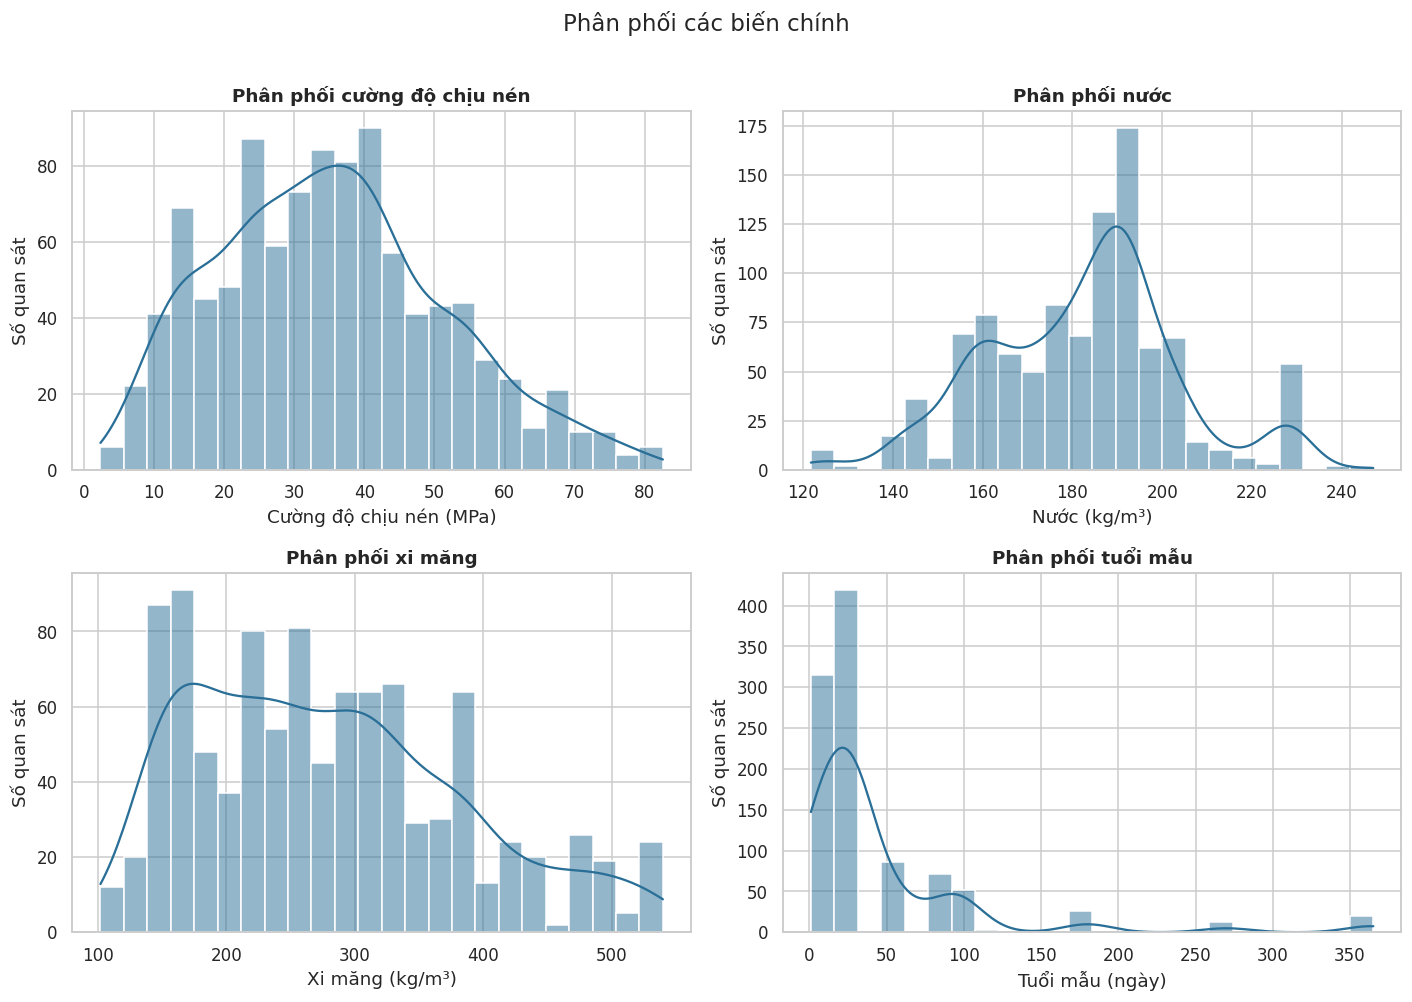

In [24]:
histogram_specs = [
    ("strength", "Cường độ chịu nén", "MPa"),
    ("water", "Nước", "kg/m³"),
    ("cement", "Xi măng", "kg/m³"),
    ("age", "Tuổi mẫu", "ngày"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (variable, title, unit) in zip(axes.flat, histogram_specs):
    sns.histplot(clean_df[variable], bins=24, kde=True, color="#2A6F97", ax=ax)
    ax.set_title(f"Phân phối {title.lower()}")
    ax.set_xlabel(f"{title} ({unit})")
    ax.set_ylabel("Số quan sát")
fig.suptitle("Phân phối các biến chính", fontsize=15, y=1.01)
plt.tight_layout()
save_figure("01_hist_kde_main_variables.png")
plt.show()

**Nhận xét.** Strength lệch phải nhẹ (skewness 0,396; trung bình 35,250 MPa cao hơn trung vị 33,798 MPa). Water gần đối xứng, cement lệch phải vừa. Age tập trung mạnh ở 28 ngày và có đuôi kéo dài đến 365 ngày, phù hợp với skewness 3,254.

### 6.2. Boxplot các thành phần cấp phối

**Vì sao chọn biểu đồ này?** Boxplot cho thấy trung vị, khoảng tứ phân vị và các điểm vượt râu trong cùng một khung. Mỗi thành phần dùng một ô riêng để tránh biến có thang đo lớn che khuất biến liều lượng nhỏ.

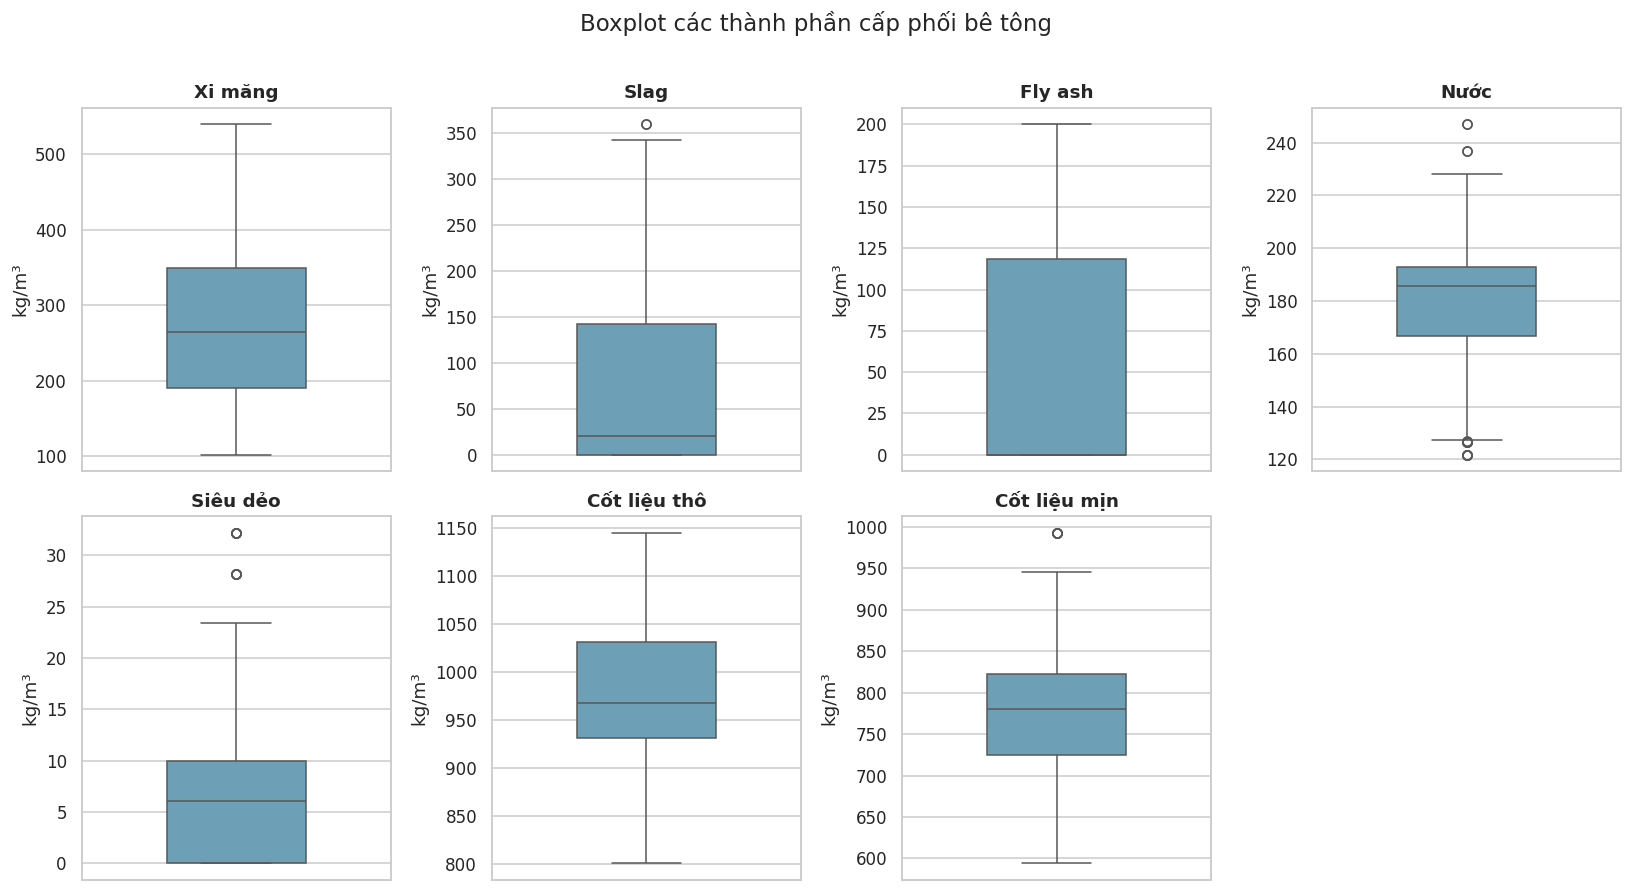

In [25]:
component_labels = {
    "cement": "Xi măng", "slag": "Slag", "fly_ash": "Fly ash",
    "water": "Nước", "superplasticizer": "Siêu dẻo",
    "coarse_agg": "Cốt liệu thô", "fine_agg": "Cốt liệu mịn",
}
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, variable in zip(axes.flat, component_labels):
    sns.boxplot(y=clean_df[variable], color="#61A5C2", width=0.45, ax=ax)
    ax.set_title(component_labels[variable])
    ax.set_xlabel("")
    ax.set_ylabel("kg/m³")
axes.flat[-1].axis("off")
fig.suptitle("Boxplot các thành phần cấp phối bê tông", fontsize=15, y=1.01)
plt.tight_layout()
save_figure("02_boxplot_components.png")
plt.show()

**Nhận xét.** Slag, fly ash và superplasticizer có hộp phân phối chạm 0 do nhiều cấp phối không sử dụng chúng. Water có 15 điểm ngoài râu IQR, superplasticizer có 10 và fine aggregate có 5; các điểm này sẽ được kiểm tra về tính hợp lệ ở phần ngoại lai thay vì xóa ngay.

### 6.3. Boxplot strength theo `age_group`

**Vì sao chọn biểu đồ này?** Boxplot theo nhóm cho phép so sánh đồng thời trung vị, độ phân tán và vùng chồng lấp của cường độ giữa ba giai đoạn dưỡng hộ.

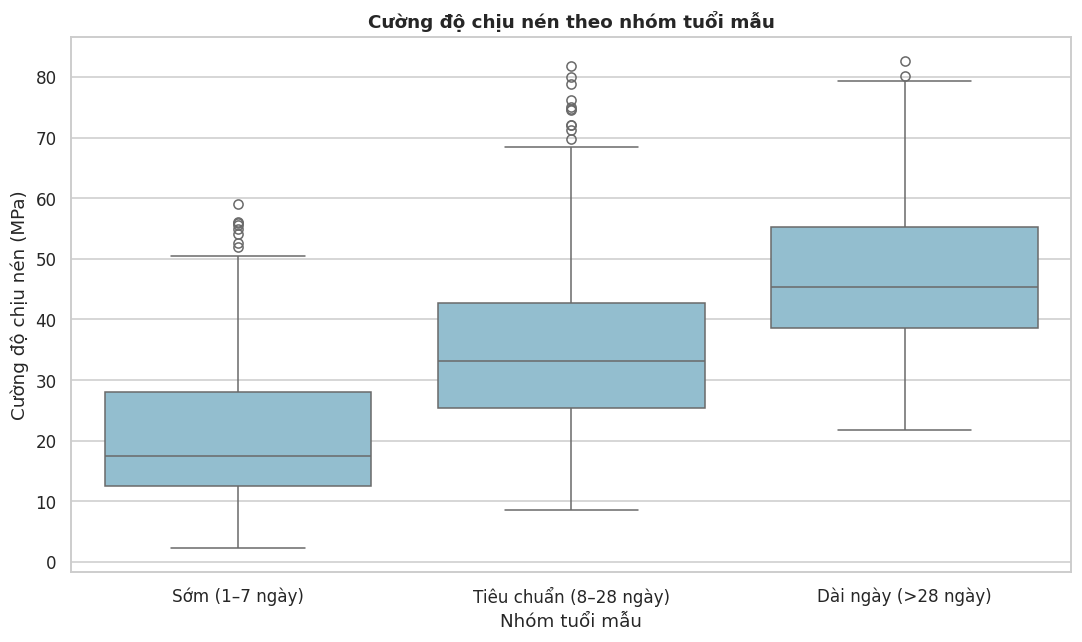

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=clean_df, x="age_group", y="strength",
    order=age_group_order, color="#89C2D9"
)
plt.title("Cường độ chịu nén theo nhóm tuổi mẫu")
plt.xlabel("Nhóm tuổi mẫu")
plt.ylabel("Cường độ chịu nén (MPa)")
plt.tight_layout()
save_figure("03_boxplot_strength_by_age_group.png")
plt.show()

**Nhận xét.** Trung vị cường độ tăng từ 17,575 MPa ở nhóm 1–7 ngày lên 33,088 MPa ở nhóm 8–28 ngày và 45,368 MPa ở nhóm >28 ngày. Tuy nhiên các hộp vẫn chồng lấp, cho thấy tuổi không phải yếu tố duy nhất quyết định strength.

### 6.4. Boxplot strength theo `scm_type`

**Vì sao chọn biểu đồ này?** Các nhóm SCM là biến phân loại không có thứ tự tự nhiên; boxplot phù hợp để so sánh toàn bộ phân phối strength giữa bốn kiểu sử dụng vật liệu.

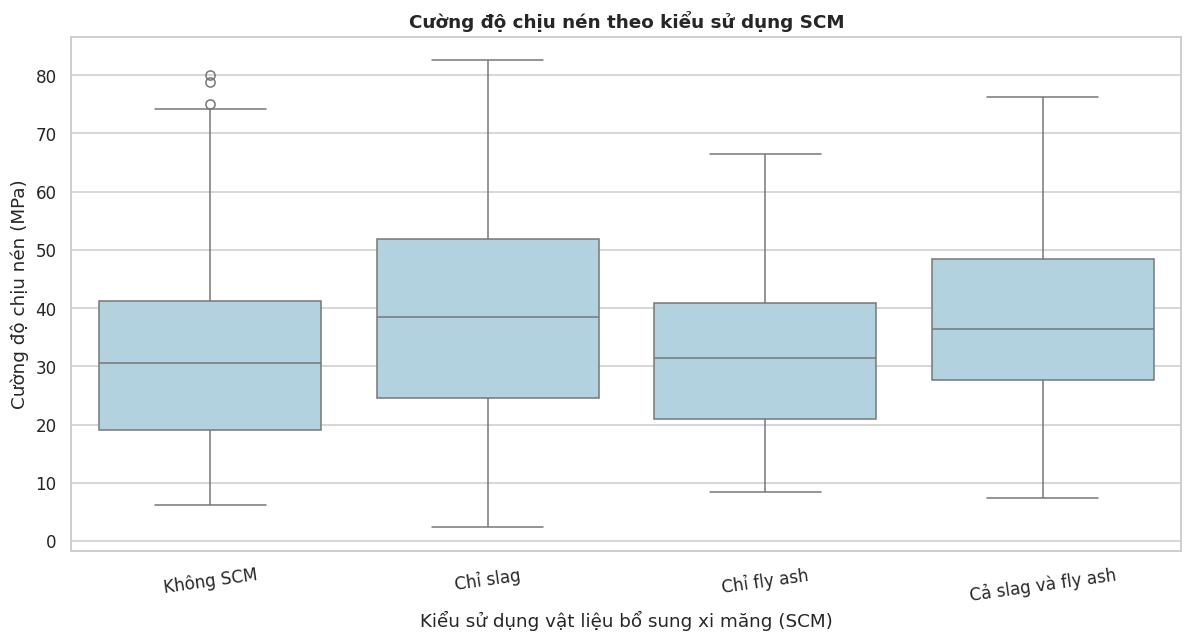

In [27]:
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=clean_df, x="scm_type", y="strength",
    order=scm_order, color="#A9D6E5"
)
plt.title("Cường độ chịu nén theo kiểu sử dụng SCM")
plt.xlabel("Kiểu sử dụng vật liệu bổ sung xi măng (SCM)")
plt.ylabel("Cường độ chịu nén (MPa)")
plt.xticks(rotation=8)
plt.tight_layout()
save_figure("04_boxplot_strength_by_scm_type.png")
plt.show()

**Nhận xét.** Trung vị strength cao nhất ở nhóm chỉ slag (38,554 MPa), tiếp theo là dùng cả slag và fly ash (36,394 MPa), chỉ fly ash (31,478 MPa) và không SCM (30,571 MPa). Đây là so sánh mô tả; các nhóm còn khác nhau về tuổi và toàn bộ cấp phối nên chưa thể diễn giải nhân quả.

### 6.5. Bar chart số quan sát theo tuổi

**Vì sao chọn biểu đồ này?** Tuổi chỉ có 14 mốc rời rạc, nên bar chart hiển thị chính xác quy mô từng mốc tốt hơn đường liên tục hoặc histogram mặc định.

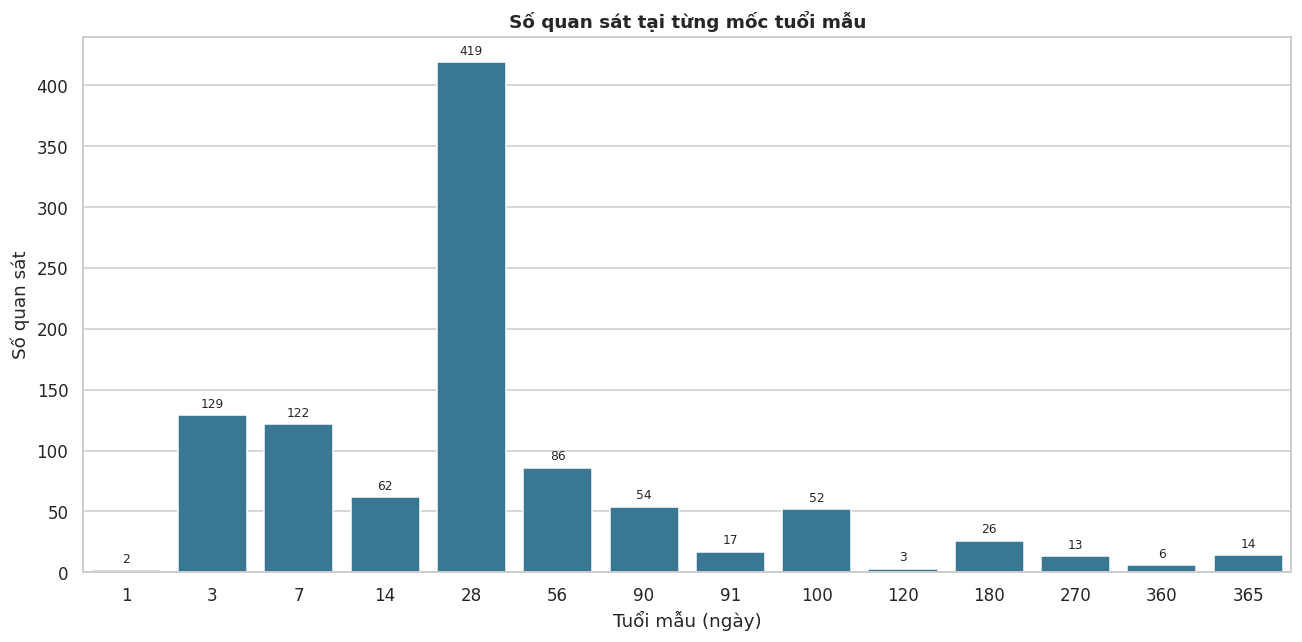

In [28]:
age_counts = clean_df["age"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=age_counts.index.astype(str), y=age_counts.values, color="#2C7DA0")
ax.bar_label(ax.containers[0], padding=3, fontsize=8)
plt.title("Số quan sát tại từng mốc tuổi mẫu")
plt.xlabel("Tuổi mẫu (ngày)")
plt.ylabel("Số quan sát")
plt.tight_layout()
save_figure("05_bar_age_counts.png")
plt.show()

**Nhận xét.** Mốc 28 ngày có 419 quan sát, chiếm 41,7% dữ liệu sau làm sạch. Các mốc 1, 120 và 360 ngày chỉ có lần lượt 2, 3 và 6 quan sát, nên thống kê riêng ở các mốc này kém ổn định.

### 6.6. Bar chart tỷ lệ kiểu sử dụng SCM

**Vì sao chọn biểu đồ này?** Bar chart tỷ lệ giúp so sánh trực tiếp mức phổ biến của bốn kiểu cấp phối SCM mà không bị ảnh hưởng bởi tổng số dòng.

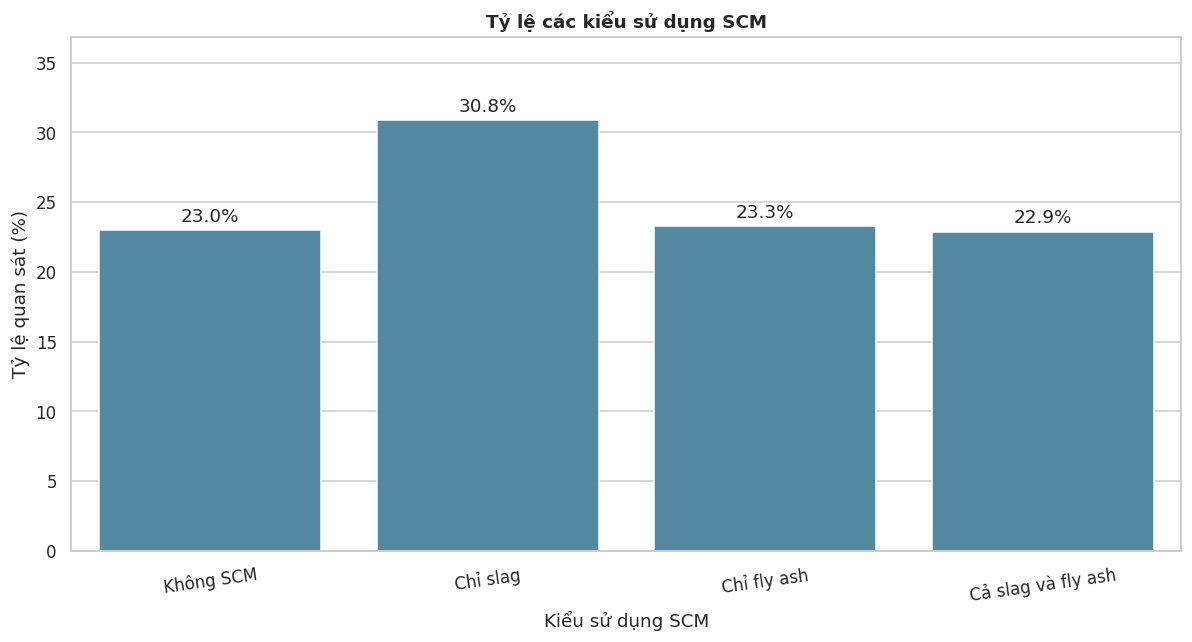

In [29]:
scm_percent = clean_df["scm_type"].value_counts(sort=False, normalize=True).mul(100)
plt.figure(figsize=(11, 6))
ax = sns.barplot(x=scm_percent.index, y=scm_percent.values, color="#468FAF")
ax.bar_label(ax.containers[0], labels=[f"{value:.1f}%" for value in scm_percent.values], padding=3)
plt.title("Tỷ lệ các kiểu sử dụng SCM")
plt.xlabel("Kiểu sử dụng SCM")
plt.ylabel("Tỷ lệ quan sát (%)")
plt.ylim(0, max(scm_percent.values) + 6)
plt.xticks(rotation=8)
plt.tight_layout()
save_figure("06_bar_scm_usage.png")
plt.show()

**Nhận xét.** 23,0% cấp phối không dùng SCM, còn 77,0% dùng ít nhất một loại. Nhóm chỉ slag lớn nhất (30,8%); ba nhóm còn lại đều xấp xỉ 23%.

### 6.7. Scatter plot strength với water, cement, log_age và w_c

**Vì sao chọn biểu đồ này?** Scatter plot giữ lại từng quan sát và đường xu hướng tuyến tính hỗ trợ nhận biết chiều quan hệ, độ phân tán và khả năng phi tuyến giữa biến mục tiêu với bốn biến giải thích quan trọng.

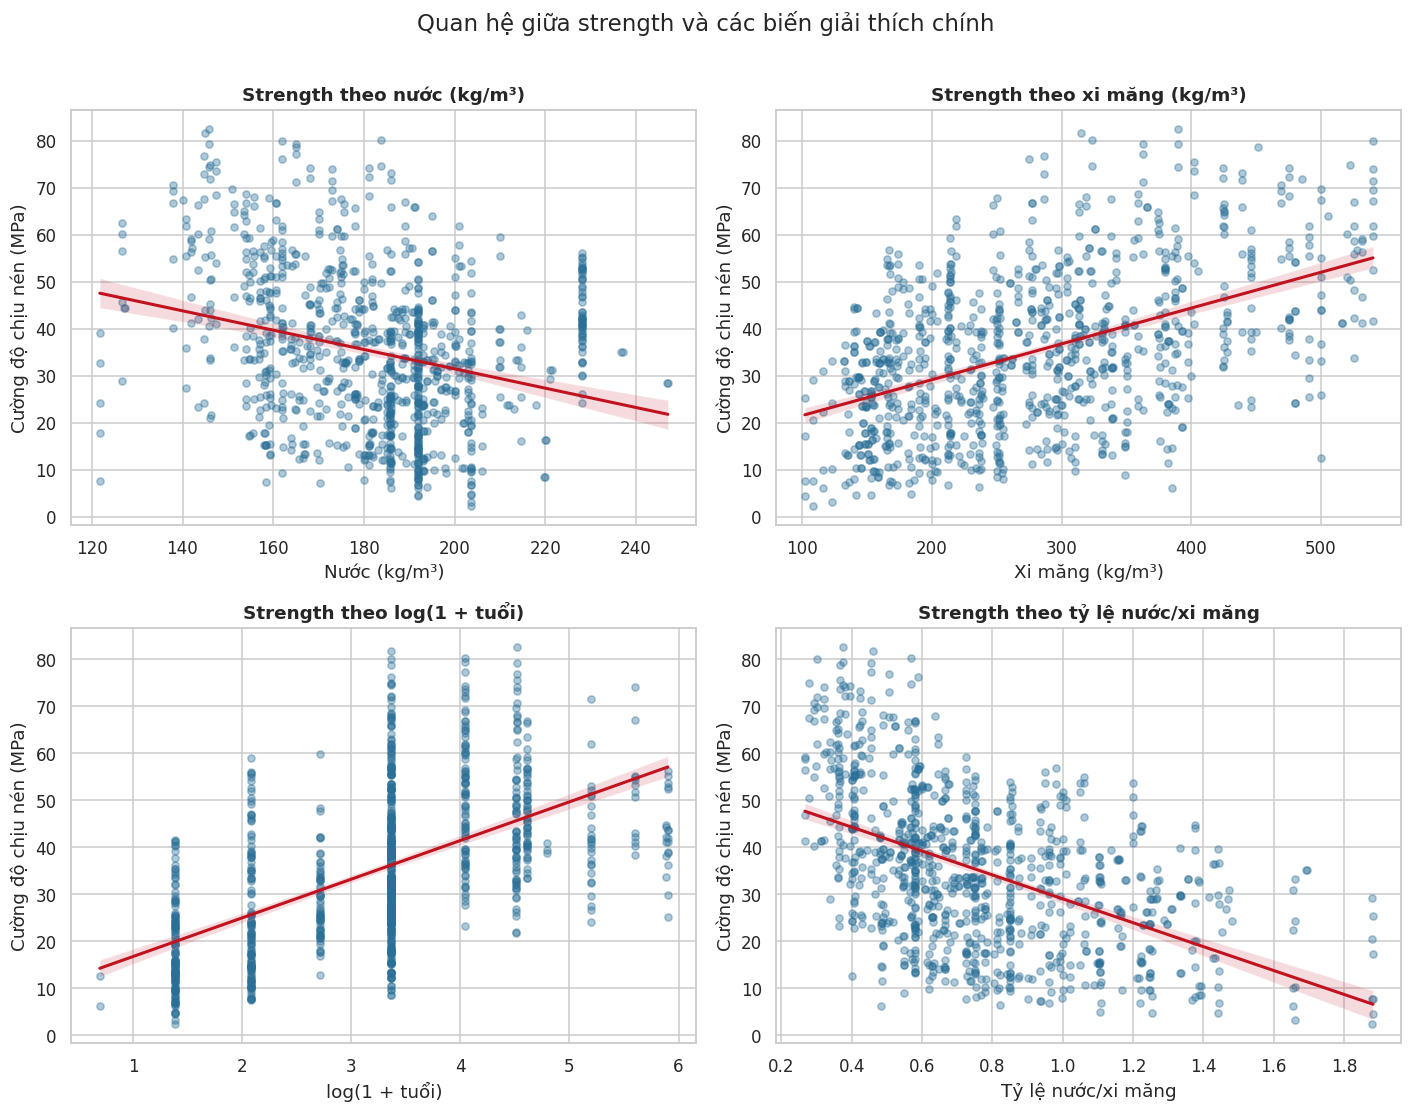

In [30]:
scatter_specs = [
    ("water", "Nước (kg/m³)"),
    ("cement", "Xi măng (kg/m³)"),
    ("log_age", "log(1 + tuổi)"),
    ("w_c", "Tỷ lệ nước/xi măng"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (variable, label) in zip(axes.flat, scatter_specs):
    sns.regplot(
        data=clean_df, x=variable, y="strength", ax=ax,
        scatter_kws={"alpha": 0.38, "s": 22, "color": "#2A6F97"},
        line_kws={"color": "#C1121F", "linewidth": 2},
    )
    ax.set_title(f"Strength theo {label.lower()}")
    ax.set_xlabel(label)
    ax.set_ylabel("Cường độ chịu nén (MPa)")
fig.suptitle("Quan hệ giữa strength và các biến giải thích chính", fontsize=15, y=1.01)
plt.tight_layout()
save_figure("07_scatter_strength_relationships.png")
plt.show()

**Nhận xét.** Tương quan Spearman với strength lần lượt là water −0,284, cement 0,461, log_age 0,605 và w_c −0,504. Age/log_age và cement có xu hướng đồng biến; water và đặc biệt w_c có xu hướng nghịch biến. Độ phân tán còn lớn, cho thấy quan hệ đa biến và có thể phi tuyến.

### 6.8. Heatmap tương quan Spearman

**Vì sao chọn biểu đồ này?** Spearman đo quan hệ đơn điệu bằng thứ hạng, phù hợp hơn Pearson khi biến lệch, có nhiều số 0 hoặc quan hệ không tuyến tính. Heatmap giúp xem đồng thời các cặp biến và phát hiện đa cộng tuyến tiềm năng.

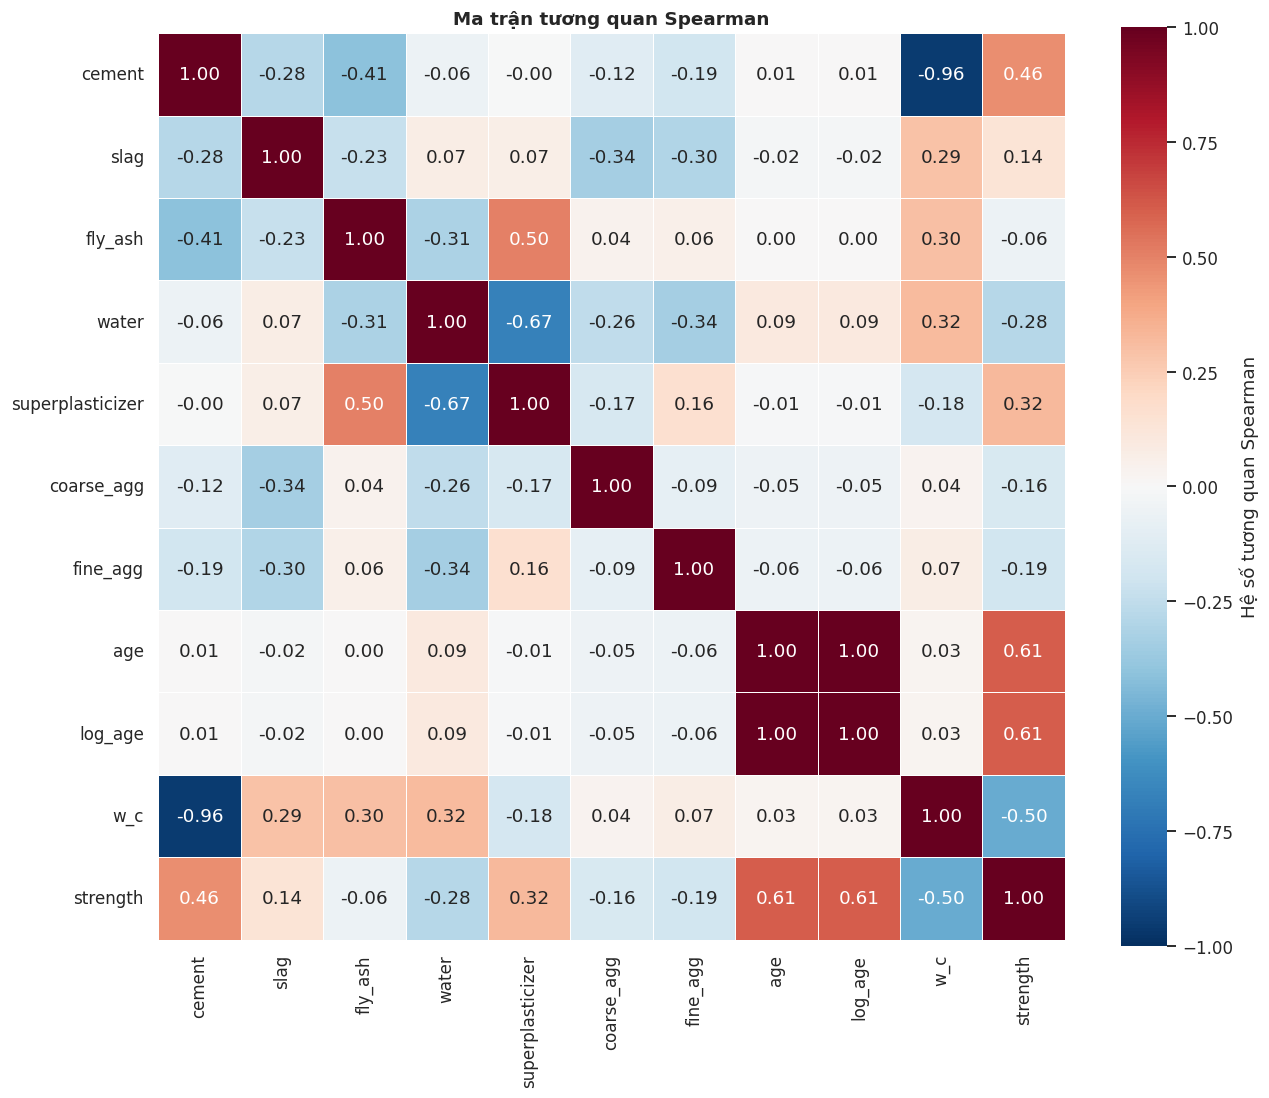

In [31]:
correlation_columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "log_age", "w_c", "strength"
]
spearman_corr = clean_df[correlation_columns].corr(method="spearman")
spearman_corr.to_csv(tables_dir / "spearman_correlation.csv", encoding="utf-8-sig")

plt.figure(figsize=(12, 10))
sns.heatmap(
    spearman_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, linewidths=0.5,
    cbar_kws={"label": "Hệ số tương quan Spearman"},
)
plt.title("Ma trận tương quan Spearman")
plt.tight_layout()
save_figure("08_heatmap_spearman.png")
plt.show()

**Nhận xét.** Strength liên hệ đơn điệu mạnh nhất với age/log_age (ρ = 0,605), tiếp theo là w_c (ρ = −0,504) và cement (ρ = 0,461). Age và log_age có cùng thứ hạng nên tương quan Spearman bằng 1; không nên đưa đồng thời cả hai vào một mô hình tuyến tính sau này.

## 7. Phân tích ngoại lai

Ba quy tắc được áp dụng cho các biến chính:

- **IQR:** ngoài khoảng Q1 − 1,5×IQR đến Q3 + 1,5×IQR; bền vững với phân phối lệch.
- **Z-score:** |Z| > 3; phù hợp nhất khi phân phối gần chuẩn.
- **Modified Z-score:** |MZ| > 3,5 dựa trên median và MAD; bền vững hơn Z-score nhưng không xác định khi MAD = 0.

Các phương pháp này là công cụ sàng lọc, không tự động kết luận một giá trị là lỗi nhập.

Tính số ngoại lai theo từng biến và từng phương pháp. Với fly ash, hơn một nửa giá trị bằng 0 làm MAD bằng 0; Modified Z-score được ghi là không áp dụng thay vì báo sai là không có ngoại lai.

In [32]:
outlier_variables = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "strength", "w_c"
]
outlier_masks = {"IQR": {}, "Z-score": {}, "Modified Z-score": {}}
outlier_rows = []

for variable in outlier_variables:
    series = clean_df[variable]
    iqr_mask, iqr_lower, iqr_upper = iqr_outlier_flags(series)
    z_mask, z_lower, z_upper = zscore_outlier_flags(series)
    mz_mask, mz_lower, mz_upper, mz_available, mad = modified_z_outlier_flags(series)

    outlier_masks["IQR"][variable] = iqr_mask
    outlier_masks["Z-score"][variable] = z_mask
    outlier_masks["Modified Z-score"][variable] = mz_mask if mz_available else None
    outlier_rows.append({
        "variable": variable,
        "IQR": int(iqr_mask.sum()),
        "Z-score": int(z_mask.sum()),
        "Modified Z-score": int(mz_mask.sum()) if mz_available else pd.NA,
        "IQR_lower": iqr_lower,
        "IQR_upper": iqr_upper,
        "MAD": mad,
        "ghi_chu_MZ": "Áp dụng" if mz_available else "Không áp dụng vì MAD = 0",
    })

outlier_comparison = pd.DataFrame(outlier_rows)
outlier_comparison.to_csv(
    tables_dir / "outlier_comparison.csv", index=False, encoding="utf-8-sig"
)
display(outlier_comparison)

,variable,IQR,Z-score,Modified Z-score,IQR_lower,IQR_upper,MAD,ghi_chu_MZ
0,cement,0,0,0,-46.800,586.480,74.660,Áp dụng
1,slag,2,4,301,-213.750,356.250,20.000,Áp dụng
2,fly_ash,0,0,<NA>,-177.405,295.675,0.000,Không áp dụng vì MAD = 0
3,water,15,2,0,127.115,232.435,12.700,Áp dụng
4,superplasticizer,10,10,0,-15.000,25.000,5.560,Áp dụng
5,coarse_agg,0,0,0,783.500,"1,179.500",46.300,Áp dụng
6,fine_agg,5,0,0,577.450,969.050,45.700,Áp dụng
7,age,59,33,59,-66.500,129.500,21.000,Áp dụng
8,strength,8,0,0,-8.494,76.886,10.721,Áp dụng
9,w_c,18,8,18,-0.038,1.523,0.184,Áp dụng


**Nhận xét.** IQR gắn cờ nhiều nhất ở age (59), w_c (18), water (15) và superplasticizer (10). Z-score bảo thủ hơn, với 33 điểm ở age, 10 ở superplasticizer và 8 ở w_c. Modified Z-score gắn cờ 301 giá trị slag vì phân phối có khối lớn gần 0; đây là dấu hiệu phương pháp nhạy với cấu trúc zero-inflated, không phải 301 lỗi dữ liệu.

Đếm số dòng được gắn cờ bởi ít nhất một biến trong mỗi phương pháp và xem mức giao nhau giữa ba phương pháp. Cách đếm theo dòng tránh cộng trùng khi một quan sát ngoại lai ở nhiều biến.

In [33]:
iqr_any = pd.DataFrame(outlier_masks["IQR"]).any(axis=1)
zscore_any = pd.DataFrame(outlier_masks["Z-score"]).any(axis=1)
available_mz_masks = {
    variable: mask for variable, mask in outlier_masks["Modified Z-score"].items()
    if mask is not None
}
modified_z_any = pd.DataFrame(available_mz_masks).any(axis=1)

outlier_overlap = pd.DataFrame({
    "IQR": iqr_any,
    "Z-score": zscore_any,
    "Modified Z-score": modified_z_any,
}).value_counts().rename("so_dong").reset_index()
outlier_method_totals = pd.DataFrame({
    "phuong_phap": ["IQR", "Z-score", "Modified Z-score"],
    "so_dong_duoc_gan_co": [int(iqr_any.sum()), int(zscore_any.sum()), int(modified_z_any.sum())],
    "ty_le_pct": [iqr_any.mean() * 100, zscore_any.mean() * 100, modified_z_any.mean() * 100],
})
outlier_overlap.to_csv(tables_dir / "outlier_overlap.csv", index=False, encoding="utf-8-sig")
display(outlier_method_totals)
display(outlier_overlap)

,phuong_phap,so_dong_duoc_gan_co,ty_le_pct
0,IQR,110,10.945
1,Z-score,57,5.672
2,Modified Z-score,347,34.527


,IQR,Z-score,Modified Z-score,so_dong
0,False,False,False,634
1,False,False,True,259
2,True,False,True,43
3,True,True,True,43
4,True,False,False,12
5,True,True,False,12
6,False,True,True,2


**Nhận xét.** IQR gắn cờ 110 dòng (10,9%), Z-score 57 dòng (5,7%) và Modified Z-score 347 dòng (34,5%). Có 634 dòng không bị phương pháp nào gắn cờ. Chênh lệch lớn giữa các phương pháp phản ánh phân phối lệch và nhiều số 0, vì vậy không có cơ sở để xóa đồng loạt các dòng được gắn cờ.

### 7.1. Xem xét bản chất từng nhóm ngoại lai

Bảng sau đối chiếu phạm vi quan sát, phạm vi các điểm bị gắn cờ và đánh giá miền giá trị. Mục tiêu là phân biệt lỗi nhập liệu với cấp phối hoặc tuổi thí nghiệm hiếm nhưng hợp lệ.

In [34]:
assessment_map = {
    "cement": "Không có ngoại lai; toàn bộ giá trị dương và nằm trong phạm vi nguồn.",
    "slag": "Mức cao đến 359,4 kg/m³ vẫn là cấp phối có thể có; nhiều số 0 làm phân phối lệch.",
    "fly_ash": "Số 0 là không sử dụng; MAD = 0 nên Modified Z-score không phù hợp.",
    "water": "Các mức 121,75–247 kg/m³ đều dương và có thể là công thức cấp phối thật.",
    "superplasticizer": "Liều cao đến 32,2 kg/m³ hiếm nhưng không mâu thuẫn logic dữ liệu.",
    "coarse_agg": "Không có ngoại lai theo ba quy tắc; toàn bộ giá trị dương.",
    "fine_agg": "Các mức cao đến 992,6 kg/m³ vẫn là lượng cốt liệu mịn hợp lệ.",
    "age": "Các mốc 180–365 ngày là lịch thử nghiệm chủ đích, không phải lỗi nhập.",
    "strength": "Các giá trị cao đến 82,599 MPa phù hợp bê tông cường độ cao trong bộ dữ liệu.",
    "w_c": "Tỷ lệ cao đến 1,882 được tính từ hai giá trị dương; cần theo dõi nhưng không phải lỗi chia.",
}

def flagged_range(series, mask):
    if mask is None:
        return "Không áp dụng"
    values = series[mask]
    if values.empty:
        return "Không có"
    return f"{values.min():.3f}–{values.max():.3f}"


review_rows = []
for variable in outlier_variables:
    review_rows.append({
        "variable": variable,
        "pham_vi_quan_sat": f"{clean_df[variable].min():.3f}–{clean_df[variable].max():.3f}",
        "pham_vi_co_IQR": flagged_range(clean_df[variable], outlier_masks["IQR"][variable]),
        "pham_vi_co_Z": flagged_range(clean_df[variable], outlier_masks["Z-score"][variable]),
        "pham_vi_co_MZ": flagged_range(clean_df[variable], outlier_masks["Modified Z-score"][variable]),
        "danh_gia": assessment_map[variable],
        "ket_luan": "Giá trị thật/hiếm; giữ lại và gắn cờ" if (
            outlier_masks["IQR"][variable].any()
            or outlier_masks["Z-score"][variable].any()
            or (
                outlier_masks["Modified Z-score"][variable] is not None
                and outlier_masks["Modified Z-score"][variable].any()
            )
        ) else "Không phát hiện ngoại lai",
    })

outlier_group_review = pd.DataFrame(review_rows)
outlier_group_review.to_csv(
    tables_dir / "outlier_group_review.csv", index=False, encoding="utf-8-sig"
)
display(outlier_group_review)

,variable,pham_vi_quan_sat,pham_vi_co_IQR,pham_vi_co_Z,pham_vi_co_MZ,danh_gia,ket_luan
0,cement,102.000–540.000,Không có,Không có,Không có,Không có ngoại lai; toàn bộ giá trị dương và n...,Không phát hiện ngoại lai
1,slag,0.000–359.400,359.400–359.400,342.100–359.400,124.100–359.400,"Mức cao đến 359,4 kg/m³ vẫn là cấp phối có thể...",Giá trị thật/hiếm; giữ lại và gắn cờ
2,fly_ash,0.000–200.100,Không có,Không có,Không áp dụng,Số 0 là không sử dụng; MAD = 0 nên Modified Z-...,Không phát hiện ngoại lai
3,water,121.750–247.000,121.750–247.000,246.900–247.000,Không có,"Các mức 121,75–247 kg/m³ đều dương và có thể l...",Giá trị thật/hiếm; giữ lại và gắn cờ
4,superplasticizer,0.000–32.200,28.200–32.200,28.200–32.200,Không có,"Liều cao đến 32,2 kg/m³ hiếm nhưng không mâu t...",Giá trị thật/hiếm; giữ lại và gắn cờ
5,coarse_agg,801.000–1145.000,Không có,Không có,Không có,Không có ngoại lai theo ba quy tắc; toàn bộ gi...,Không phát hiện ngoại lai
6,fine_agg,594.000–992.600,992.600–992.600,Không có,Không có,"Các mức cao đến 992,6 kg/m³ vẫn là lượng cốt l...",Giá trị thật/hiếm; giữ lại và gắn cờ
7,age,1.000–365.000,180.000–365.000,270.000–365.000,180.000–365.000,Các mốc 180–365 ngày là lịch thử nghiệm chủ đí...,Giá trị thật/hiếm; giữ lại và gắn cờ
8,strength,2.332–82.599,77.297–82.599,Không có,Không có,"Các giá trị cao đến 82,599 MPa phù hợp bê tông...",Giá trị thật/hiếm; giữ lại và gắn cờ
9,w_c,0.267–1.882,1.655–1.882,1.879–1.882,1.655–1.882,"Tỷ lệ cao đến 1,882 được tính từ hai giá trị d...",Giá trị thật/hiếm; giữ lại và gắn cờ


**Nhận xét.** Không nhóm nào cho thấy dấu hiệu rõ ràng của lỗi nhập như giá trị âm, tuổi ngoài 1–365 ngày hoặc thành phần bắt buộc bằng 0. Ngoại lai chủ yếu là mốc tuổi dài, cấp phối cực trị và mẫu cường độ cao; đây đều có thể là quan sát phòng thí nghiệm hợp lệ.

### 7.2. Trực quan so sánh số ngoại lai

**Vì sao chọn biểu đồ này?** Bar chart nhóm cho thấy ngay phương pháp nào nhạy với từng biến và làm nổi bật trường hợp Modified Z-score gắn cờ quá nhiều ở slag.

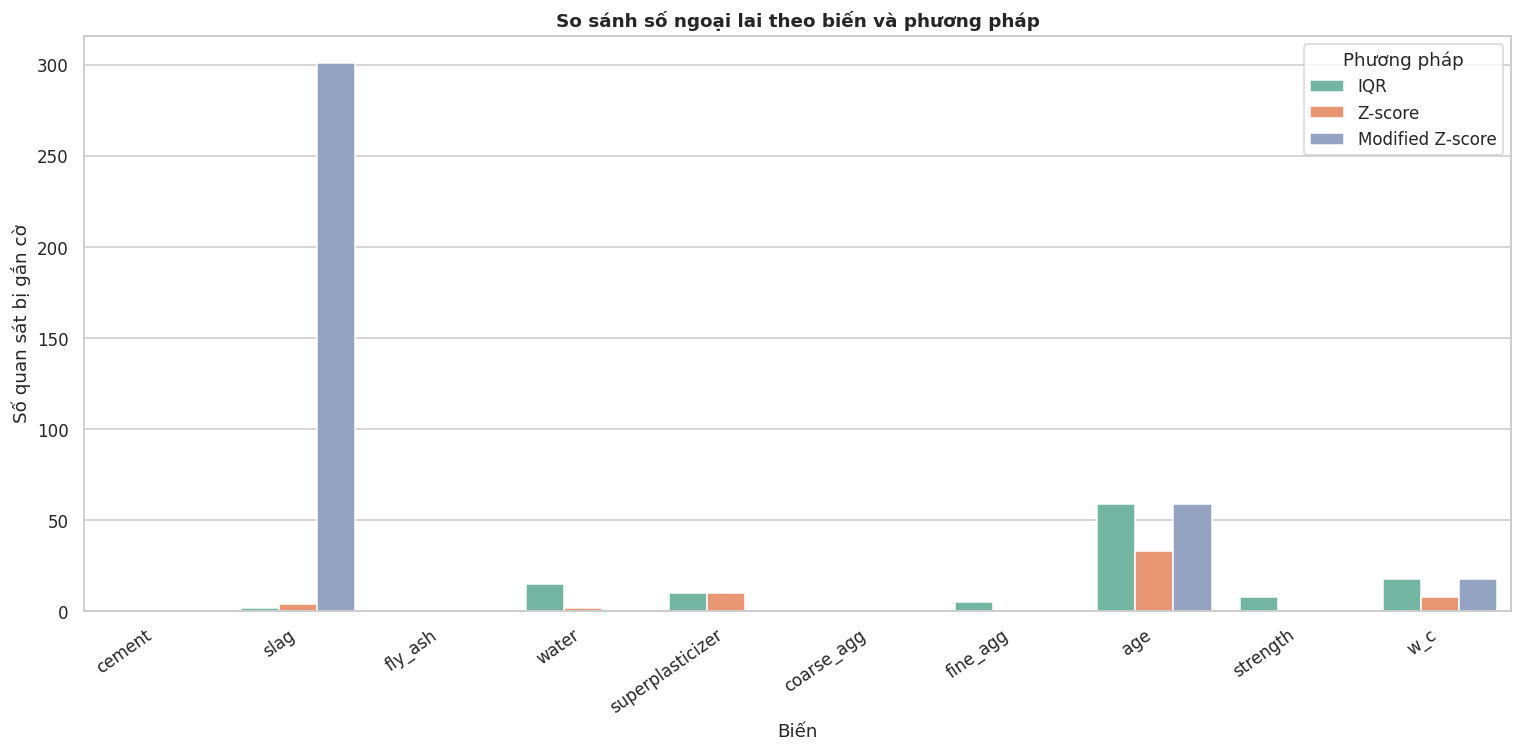

In [35]:
outlier_plot_data = outlier_comparison.melt(
    id_vars="variable",
    value_vars=["IQR", "Z-score", "Modified Z-score"],
    var_name="phuong_phap",
    value_name="so_ngoai_lai",
).dropna()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=outlier_plot_data, x="variable", y="so_ngoai_lai",
    hue="phuong_phap", palette="Set2"
)
plt.title("So sánh số ngoại lai theo biến và phương pháp")
plt.xlabel("Biến")
plt.ylabel("Số quan sát bị gắn cờ")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Phương pháp")
plt.tight_layout()
save_figure("09_bar_outlier_comparison.png")
plt.show()

**Nhận xét.** IQR và Z-score cho kết quả tương đối gần nhau ở superplasticizer, còn Modified Z-score khác biệt mạnh ở slag. Điều này củng cố quyết định không dùng một quy tắc đơn lẻ để xóa dữ liệu.

### 7.3. Quyết định xử lý ngoại lai

Không xóa ngoại lai vì chưa có bằng chứng lỗi nhập. Thay vào đó, giữ nguyên giá trị và thêm ba cờ mức dòng (`outlier_iqr_any`, `outlier_zscore_any`, `outlier_mad_any`) để các bước sau có thể kiểm tra độ nhạy khi cần. Đây là một hành động xử lý có thể truy vết và không làm mất các cấp phối thí nghiệm hiếm.

In [36]:
clean_df["outlier_iqr_any"] = iqr_any
clean_df["outlier_zscore_any"] = zscore_any
clean_df["outlier_mad_any"] = modified_z_any

cleaning_records.append({
    "buoc": "Xử lý ngoại lai",
    "so_dong_truoc": len(clean_df),
    "so_dong_loai": 0,
    "so_dong_sau": len(clean_df),
    "ly_do": "Không có bằng chứng lỗi nhập; giữ giá trị phòng thí nghiệm và thêm cờ theo 3 phương pháp.",
})
cleaning_log = pd.DataFrame(cleaning_records)
cleaning_log.to_csv(tables_dir / "cleaning_log.csv", index=False, encoding="utf-8-sig")
display(clean_df[["outlier_iqr_any", "outlier_zscore_any", "outlier_mad_any"]].sum().to_frame("so_dong"))
display(cleaning_log)

,so_dong
outlier_iqr_any,110
outlier_zscore_any,57
outlier_mad_any,347


,buoc,so_dong_truoc,so_dong_loai,so_dong_sau,ly_do
0,Nạp dữ liệu gốc,1030,0,1030,Giữ nguyên toàn bộ bản ghi khi đọc tệp nguồn.
1,Xóa dòng trùng hoàn toàn,1030,25,1005,Các dòng giống nhau ở cả 9 cột không có mã mẫu...
2,Kiểm tra giá trị thiếu,1005,0,1005,Không có NaN; không cần điền khuyết hoặc loại ...
3,Kiểm tra giá trị không dương bất hợp lý,1005,0,1005,"Không có cement, water, aggregate, age hoặc st..."
4,Xác nhận số 0 hợp lệ ở vật liệu tùy chọn,1005,0,1005,"Số 0 ở slag, fly_ash và superplasticizer nghĩa..."
5,Xử lý ngoại lai,1005,0,1005,Không có bằng chứng lỗi nhập; giữ giá trị phòn...


**Nhận xét.** Tập dữ liệu vẫn có 1.005 dòng. Các cờ ngoại lai cho phép tái lập đúng các tập con 110, 57 và 347 dòng mà không sửa hoặc winsorize giá trị gốc.

## 8. Nhận xét tổng quan

1. Dữ liệu gốc đầy đủ nhưng có 25 dòng trùng hoàn toàn; sau làm sạch còn 1.005 quan sát.
2. Tuổi mẫu chỉ gồm 14 mốc và tập trung mạnh ở 28 ngày (419 dòng, 41,7%), làm `age` lệch phải; `log_age` cân đối hơn đáng kể.
3. Cường độ trung bình là 35,250 MPa, trung vị 33,798 MPa; phân phối lệch phải nhẹ và trải từ 2,332 đến 82,599 MPa.
4. Strength có quan hệ đơn điệu dương mạnh nhất với tuổi (ρ = 0,605), dương với cement (ρ = 0,461), và âm với tỷ lệ nước/xi măng (ρ = −0,504).
5. Trung vị strength tăng rõ theo nhóm tuổi: 17,575 MPa, 33,088 MPa và 45,368 MPa. Tuy vậy, các nhóm chồng lấp nên cần xem đồng thời cấp phối.
6. 77,0% cấp phối dùng ít nhất một SCM. Nhóm chỉ slag có trung vị strength cao nhất, nhưng đây chưa phải bằng chứng nhân quả vì các yếu tố khác chưa được kiểm soát.
7. Ngoại lai giữa các phương pháp khác nhau lớn, nhất là Modified Z-score với slag zero-inflated. Các giá trị cực trị đều hợp lý về miền, nên được giữ và gắn cờ.

## 9. Xuất dữ liệu đã xử lý

Tệp `cleaned.csv` giữ 9 cột gốc, 5 biến phụ trợ và 3 cờ ngoại lai. Dữ liệu được xuất với mã hóa UTF-8 có BOM để hiển thị tốt trong các phần mềm bảng tính.

In [40]:
export_columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "strength",
    "log_age", "w_c", "age_group", "scm_type", "strength_level",
    "outlier_iqr_any", "outlier_zscore_any", "outlier_mad_any",
]
cleaned_path = processed_dir / "cleaned.csv"
clean_df[export_columns].to_csv(cleaned_path, index=False, encoding="utf-8-sig")

**Nhận xét.** Tệp xuất có 1.005 dòng và 17 cột. Không có dòng nào bị loại thêm do ngoại lai.

Tạo README ngắn trong cùng thư mục để mô tả cột, ngưỡng phân nhóm và quy tắc làm sạch. Tài liệu này giúp người dùng dữ liệu đã xử lý không phải mở notebook để hiểu cấu trúc.

In [38]:
readme_lines = [
    "# Dữ liệu bê tông đã xử lý",
    "",
    "`cleaned.csv` được tạo từ `data/raw/Concrete_Data.xls` bởi notebook `notebooks/01_eda.ipynb`.",
    "",
    "## Quy mô và quy tắc làm sạch",
    "",
    "- Dữ liệu gốc: 1.030 dòng, 9 cột.",
    "- Xóa 25 dòng trùng hoàn toàn; dữ liệu cuối: 1.005 dòng.",
    "- Không có NaN và không có giá trị không dương ở cement, water, coarse_agg, fine_agg, age, strength.",
    "- Giữ số 0 ở slag, fly_ash, superplasticizer vì có nghĩa là không sử dụng.",
    "- Không xóa/winsorize ngoại lai; giữ nguyên giá trị thí nghiệm và thêm cờ theo dòng.",
    "",
    "## Các cột",
    "",
    "- `cement`, `slag`, `fly_ash`, `water`, `superplasticizer`, `coarse_agg`, `fine_agg`: kg/m³.",
    "- `age`: tuổi mẫu, ngày.",
    "- `strength`: cường độ chịu nén, MPa.",
    "- `log_age`: `log(1 + age)`.",
    "- `w_c`: `water / cement`.",
    "- `age_group`: 1–7 ngày; 8–28 ngày; >28 ngày.",
    "- `scm_type`: không SCM; chỉ slag; chỉ fly ash; cả slag và fly ash.",
    f"- `strength_level`: thấp ≤ {strength_q1:.3f} MPa; trung bình ({strength_q1:.3f}, {strength_q3:.3f}] MPa; cao > {strength_q3:.3f} MPa.",
    "- `outlier_iqr_any`, `outlier_zscore_any`, `outlier_mad_any`: cờ ngoại lai ở ít nhất một biến chính theo từng phương pháp.",
    "",
    "## Lưu ý",
    "",
    "Modified Z-score không áp dụng riêng cho `fly_ash` vì MAD bằng 0. Các cờ ngoại lai dùng để phân tích độ nhạy, không phải nhãn lỗi dữ liệu.",
    "",
]
readme_text = "\n".join(readme_lines)
readme_path = processed_dir / "README.md"
readme_path.write_text(readme_text, encoding="utf-8")
print(f"Đã lưu: {readme_path}")

Đã lưu: C:\Users\Phong\Desktop\concrete-compressive-strength-analysis\data\processed\README.md


**Nhận xét.** README ghi rõ nguồn gốc, quy tắc khử trùng, cách hiểu số 0, ngưỡng phân nhóm và ý nghĩa của các cờ ngoại lai.

### Kiểm tra đầu ra

Bước cuối đọc lại tệp CSV và kiểm tra các điều kiện cốt lõi: số dòng, số cột, giá trị thiếu, trùng ở 9 cột gốc, số hình và số bảng đã lưu.

In [39]:
reloaded = pd.read_csv(cleaned_path)
validation = pd.Series({
    "so_dong_cleaned_csv": len(reloaded),
    "so_cot_cleaned_csv": reloaded.shape[1],
    "tong_gia_tri_thieu": int(reloaded.isna().sum().sum()),
    "so_dong_trung_theo_9_cot_goc": int(reloaded[short_columns].duplicated().sum()),
    "so_hinh_png": len(list(figures_dir.glob("*.png"))),
    "so_bang_csv": len(list(tables_dir.glob("*.csv"))),
}, name="ket_qua")

assert validation["so_dong_cleaned_csv"] == 1005
assert validation["so_cot_cleaned_csv"] == 17
assert validation["tong_gia_tri_thieu"] == 0
assert validation["so_dong_trung_theo_9_cot_goc"] == 0
assert validation["so_hinh_png"] >= 9
assert (processed_dir / "README.md").exists()
display(validation.to_frame())
print("Kiểm tra đầu ra: ĐẠT")

,ket_qua
so_dong_cleaned_csv,1005
so_cot_cleaned_csv,17
tong_gia_tri_thieu,0
so_dong_trung_theo_9_cot_goc,0
so_hinh_png,9
so_bang_csv,8


Kiểm tra đầu ra: ĐẠT
